# Dynamic-A Simulation Hyperparameter Explorer

Use this notebook to inspect how the dynamic episodic simulator generates traces before launching locked validation runs. Edit the parameter cell, run top to bottom, and compare fluorescence, latent calcium, event rasters, phase spans, and derived representations.

The default scenario uses alternating adjacency matrices for rise phases and a stochastic-independent fall state, so falling transients are graph-independent negative-control segments rather than downstream effects of the rise generator.

<!-- reviewer-resume-contract -->
## Execution and resume contract

This notebook is aligned with the reviewer-revision implementation. Expensive work is checkpointed and safe to restart with the same configuration. Do not change methods, seeds, thresholds, or output paths while resuming. Saved outputs remain provisional until the compute-machine run and verification gates complete.


In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else start.resolve()
    for candidate in (start, *start.parents):
        package_src = candidate / "src" / "calcium_transient_rising_flank"
        if package_src.is_dir():
            return candidate
        nested = candidate / "calcium-transient-rising-flank"
        if (nested / "src" / "calcium_transient_rising_flank").is_dir():
            return nested
    raise RuntimeError("Run from the repository, package root, or notebooks directory.")


PROJECT_ROOT = find_project_root()
src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/sadiqadedayo/Documents/projects/rising_flanks/calcium-transient-rising-flank


In [2]:
from dataclasses import replace
import hashlib
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from calcium_transient_rising_flank import (
    DynamicSimulationConfig,
    build_representations,
    rise_flank_candidate_pairs,
)
from calcium_transient_rising_flank.validation import simulate_calcium_dataset as _simulate_calcium_dataset
from calcium_transient_rising_flank.checkpointing import atomic_write_pickle, load_pickle

RESUME = True
IMPLEMENTATION_REVISION = 'reviewer-2026-08-v2'
SIMULATION_CHECKPOINT_DIR = PROJECT_ROOT / 'outputs' / 'notebook_checkpoints' / 'dynamic_explorer'

def simulate_calcium_dataset(*args, **kwargs):
    payload = pickle.dumps((IMPLEMENTATION_REVISION, args, kwargs), protocol=pickle.HIGHEST_PROTOCOL)
    digest = hashlib.sha256(payload).hexdigest()
    checkpoint = SIMULATION_CHECKPOINT_DIR / f'{digest}.pkl'
    if RESUME and checkpoint.is_file():
        return load_pickle(checkpoint)
    result = _simulate_calcium_dataset(*args, **kwargs)
    atomic_write_pickle(checkpoint, result)
    return result

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})


## Parameters

Edit this cell to see how the data-generation mechanism changes. Keep `MIN_RISE_LENGTH >= 20`, `RISE_WAVEFORM_LENGTH >= 1`, and `FALL_TO_RISE_RATIO_MIN > 2.0` to match the intended discontinuous rise/fall design. Set `RISE_WAVEFORM_LENGTH = 20` for a 20-sample rise drive. Keep `FALL_INITIAL_CEILING_FRACTION <= 1.0` to prevent stochastic fall resets from jumping above the preceding rise endpoint. Use `TAU`, `N_PASTS`, `MIN_RISE_RUN_SAMPLES`, and the rise-match settings to inspect which extracted runs would enter the candidate screen and how much lag-history context would be retained.

In [3]:
RANDOM_STATE = 7
N_STEPS = 420

N_EPISODES = 4
MIN_RISE_LENGTH = 20
MAX_RISE_LENGTH = 30
RISE_WAVEFORM_LENGTH = 20
FALL_TO_RISE_RATIO_MIN = 2.1
FALL_TO_RISE_RATIO_MAX = 3.2

GAMMA_RISE = 0.90
GAMMA_FALL = 0.92
NOISE_STD = 0.025
SHARED_NOISE_STD = 0.005

SPONTANEOUS_RATE = 0.025
TRANSMISSION_PROBABILITY = 0.80
PROPAGATION_DELAY = 1
INITIAL_ACTIVATION_PROBABILITY = 0.70
RISE_GAIN = 1.00

FALL_STATE_MODE = "stochastic_independent"
FALL_INITIAL_SCALE = 1.00
FALL_INITIAL_CEILING_FRACTION = 1.00
FALL_NOISE_RATE = 0.05
FALL_NOISE_SCALE = 0.02

TOPOLOGY_MODE = "sequence"  # "sequence" or "generated"
EDGE_DROPOUT_PROBABILITY = 0.20
EDGE_ADDITION_PROBABILITY = 0.02
SOURCE_DROPOUT_PROBABILITY = 0.15
SOURCE_RECRUITMENT_PROBABILITY = 0.25
SOURCE_RECRUITMENT_EDGE_PROBABILITY = 0.25
REPRESENTATION_TOLERANCE = 0.0

TAU = None  # set e.g. 2 to match only lag-2 rise onsets
N_PASTS = 5
MIN_RISE_RUN_SAMPLES = 1
RISE_MATCH_MIN_LAG = TAU if TAU is not None else 1
RISE_MATCH_MAX_LAG = TAU if TAU is not None else 4
RISE_MATCH_MIN_OVERLAP_SAMPLES = None
RISE_MATCH_MIN_OVERLAP_FRACTION = 0.5
RISE_RUN_CONTEXT_SAMPLES = N_PASTS

A_CORE = np.array(
    [
        [False, True, False, False, False],
        [False, False, False, False, False],
        [False, False, False, True, False],
        [False, False, False, False, False],
        [False, False, False, False, False],
    ],
    dtype=bool,
)
A1_SPECIFIC = np.array(
    [
        [False, False, False, False, False],
        [False, False, True, False, False],
        [False, False, False, False, False],
        [False, False, False, False, False],
        [False, False, False, False, False],
    ],
    dtype=bool,
)
A2_SPECIFIC = np.array(
    [
        [False, False, False, False, False],
        [False, False, False, False, False],
        [False, False, False, False, False],
        [False, False, False, False, False],
        [False, False, True, False, False],
    ],
    dtype=bool,
)
A1 = A_CORE | A1_SPECIFIC
A2 = A_CORE | A2_SPECIFIC
BASE_ADJACENCY = A1 | A2
ACTIVE_NODE_SEQUENCE = (
    np.array([True, True, True, True, False]),
    np.array([True, True, True, True, True]),
)

In [4]:
if TOPOLOGY_MODE == "sequence":
    topology_kwargs = {
        "edge_dropout_probability": 0.0,
        "edge_addition_probability": 0.0,
        "adjacency_sequence": (A1, A2),
        "active_node_sequence": ACTIVE_NODE_SEQUENCE,
    }
elif TOPOLOGY_MODE == "generated":
    topology_kwargs = {
        "edge_dropout_probability": EDGE_DROPOUT_PROBABILITY,
        "edge_addition_probability": EDGE_ADDITION_PROBABILITY,
        "source_dropout_probability": SOURCE_DROPOUT_PROBABILITY,
        "source_recruitment_probability": SOURCE_RECRUITMENT_PROBABILITY,
        "source_recruitment_edge_probability": SOURCE_RECRUITMENT_EDGE_PROBABILITY,
    }
else:
    raise ValueError("TOPOLOGY_MODE must be 'sequence' or 'generated'")

dynamic_config = DynamicSimulationConfig(
    n_episodes=N_EPISODES,
    min_rise_length=MIN_RISE_LENGTH,
    max_rise_length=MAX_RISE_LENGTH,
    rise_waveform_length=RISE_WAVEFORM_LENGTH,
    fall_to_rise_ratio_min=FALL_TO_RISE_RATIO_MIN,
    fall_to_rise_ratio_max=FALL_TO_RISE_RATIO_MAX,
    propagation_delay=PROPAGATION_DELAY,
    initial_activation_probability=INITIAL_ACTIVATION_PROBABILITY,
    fall_noise_rate=FALL_NOISE_RATE,
    fall_noise_scale=FALL_NOISE_SCALE,
    fall_state_mode=FALL_STATE_MODE,
    fall_initial_scale=FALL_INITIAL_SCALE,
    fall_initial_ceiling_fraction=FALL_INITIAL_CEILING_FRACTION,
    rise_gain=RISE_GAIN,
    gamma_fall=GAMMA_FALL,
    **topology_kwargs,
)

dataset = simulate_calcium_dataset(
    BASE_ADJACENCY,
    n_steps=N_STEPS,
    gamma=GAMMA_RISE,
    noise_std=NOISE_STD,
    shared_noise_std=SHARED_NOISE_STD,
    spontaneous_rate=SPONTANEOUS_RATE,
    transmission_probability=TRANSMISSION_PROBABILITY,
    random_state=RANDOM_STATE,
    propagation_delay=PROPAGATION_DELAY,
    simulator_mode="episodic_dynamic",
    dynamic_config=dynamic_config,
)

print(f"fluorescence shape: {dataset.fluorescence.shape}")
print(f"episodes: {len(dataset.episodes)}")
print(f"fall propagated events: {0 if dataset.propagated_events is None else dataset.propagated_events[:, dataset.phase_labels == 2].sum():.0f}")
print(f"union truth edges: {int(dataset.union_adjacency.sum())}")
if dataset.edge_prevalence is not None:
    print(f"mean active-edge prevalence: {dataset.edge_prevalence[dataset.union_adjacency].mean():.2f}")

fluorescence shape: (5, 420)
episodes: 4
fall propagated events: 0
union truth edges: 4
mean active-edge prevalence: 0.75


In [5]:
def episode_summary(ds) -> pd.DataFrame:
    rows = []
    for index, episode in enumerate(ds.episodes, start=1):
        fall_prop = 0.0
        if ds.propagated_events is not None:
            fall_prop = float(ds.propagated_events[:, episode.fall_start : episode.fall_stop].sum())
        rows.append(
            {
                "episode": index,
                "rise_start": episode.rise_start,
                "rise_stop": episode.rise_stop,
                "rise_length": episode.rise_length,
                "rise_waveform_length": dynamic_config.rise_waveform_length,
                "fall_start": episode.fall_start,
                "fall_stop": episode.fall_stop,
                "fall_length": episode.fall_length,
                "fall_to_rise": episode.fall_length / episode.rise_length,
                "active_edges": int(np.count_nonzero(episode.adjacency)),
                "fall_propagated_total": fall_prop,
                "fall_initial_ceiling_fraction": dynamic_config.fall_initial_ceiling_fraction,
            }
        )
    return pd.DataFrame(rows)


def add_phase_spans(ax, ds) -> None:
    for episode in ds.episodes:
        ax.axvspan(episode.rise_start, episode.rise_stop, color="#4c78a8", alpha=0.12, lw=0)
        ax.axvspan(episode.fall_start, episode.fall_stop, color="#f58518", alpha=0.10, lw=0)


summary = episode_summary(dataset)
display(summary)

,episode,rise_start,rise_stop,rise_length,rise_waveform_length,fall_start,fall_stop,fall_length,fall_to_rise,active_edges,fall_propagated_total,fall_initial_ceiling_fraction
0,1,0,30,30,20,30,114,84,2.800000,3,0.0,1.0
1,2,114,139,25,20,139,204,65,2.600000,3,0.0,1.0
2,3,204,228,24,20,228,287,59,2.458333,3,0.0,1.0
3,4,287,316,29,20,316,395,79,2.724138,3,0.0,1.0


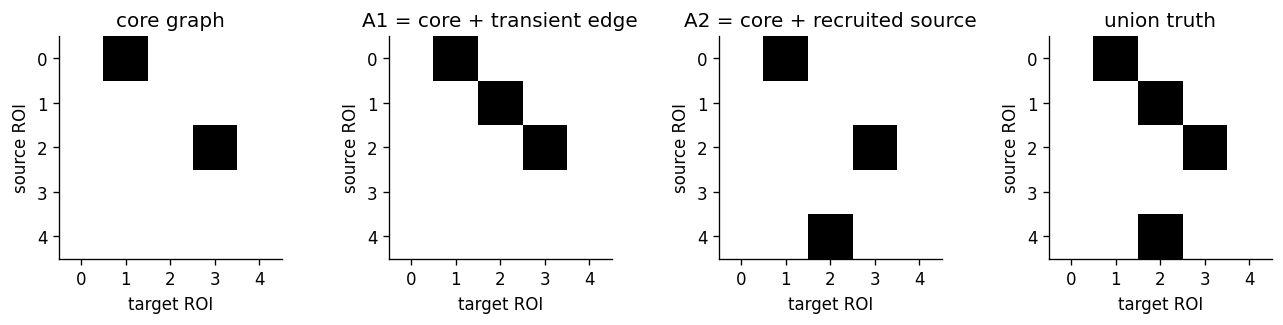

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(11, 2.6), constrained_layout=True)
matrices = (A_CORE, A1, A2, dataset.adjacency)
titles = ("core graph", "A1 = core + transient edge", "A2 = core + recruited source", "union truth")
for ax, matrix, title in zip(axes, matrices, titles, strict=True):
    ax.imshow(matrix.astype(int), cmap="Greys", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("target ROI")
    ax.set_ylabel("source ROI")
    ax.set_xticks(range(matrix.shape[1]))
    ax.set_yticks(range(matrix.shape[0]))
plt.show()

## Figure-4-Style Rise Extraction Overlay

Red points mark samples selected by the rising-flank representation. The shaded bands still show the simulated episode schedule.


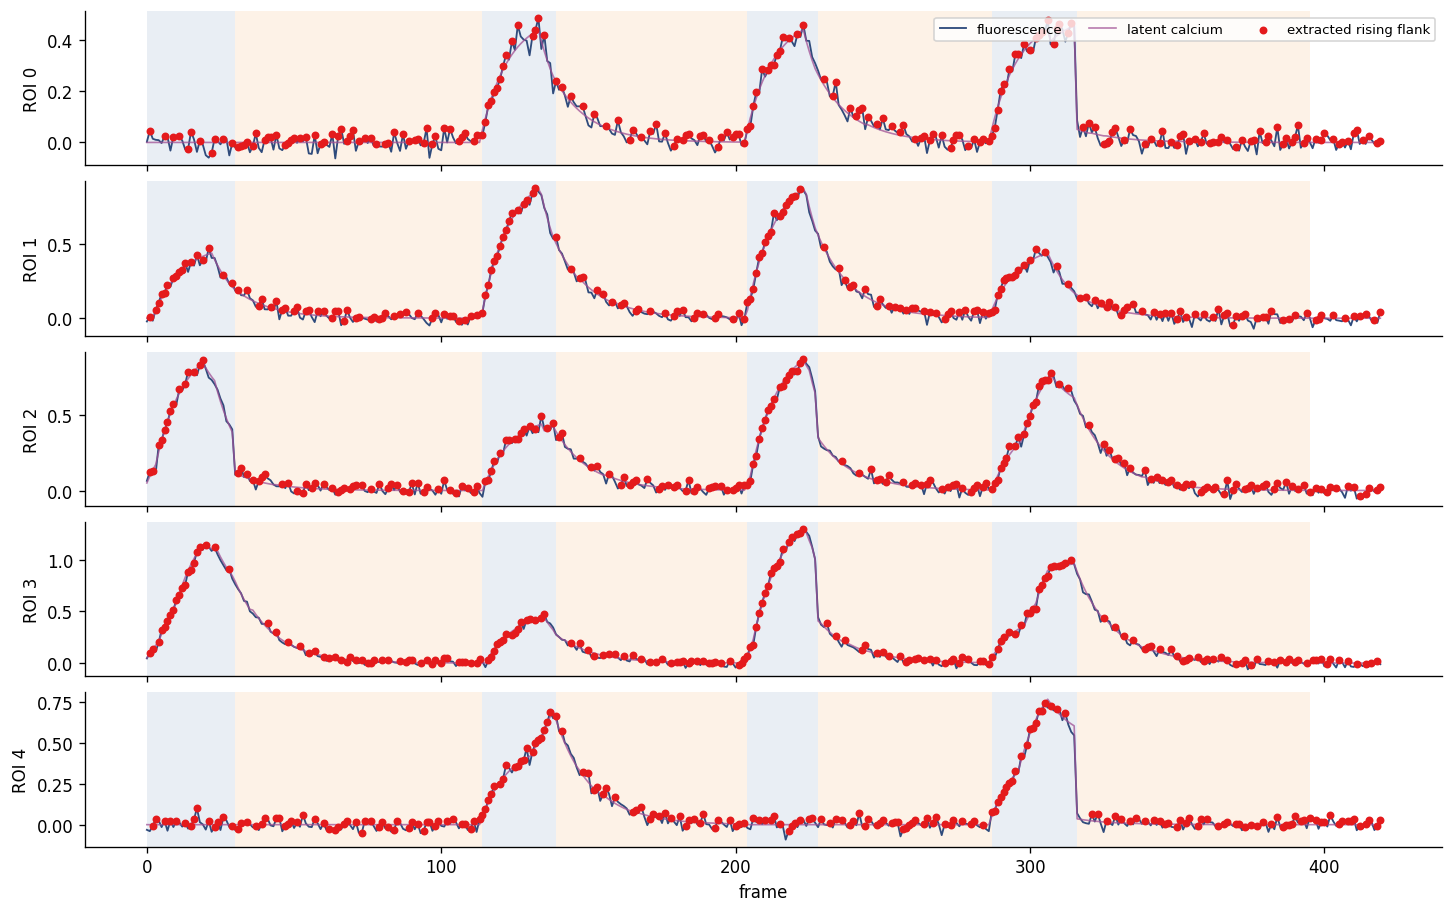

In [7]:
preview_bundle = build_representations(
    dataset.fluorescence,
    tolerance=REPRESENTATION_TOLERANCE,
    gamma=GAMMA_RISE,
)

max_rois = min(5, dataset.fluorescence.shape[0])
fig, axes = plt.subplots(
    max_rois,
    1,
    figsize=(12, 1.5 * max_rois),
    sharex=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)
time = np.arange(dataset.fluorescence.shape[1])
for roi, ax in enumerate(axes):
    add_phase_spans(ax, dataset)
    ax.plot(
        time,
        dataset.fluorescence[roi],
        color="#2f4b7c",
        lw=1.1,
        label="fluorescence",
    )
    ax.plot(
        time,
        dataset.calcium[roi],
        color="#a05195",
        lw=1.0,
        alpha=0.75,
        label="latent calcium",
    )
    rise_times = np.flatnonzero(preview_bundle.rise[roi] > 0.0)
    if rise_times.size:
        ax.scatter(
            rise_times,
            dataset.fluorescence[roi, rise_times],
            color="#e41a1c",
            s=14,
            zorder=3,
            label="extracted rising flank",
        )
    ax.set_ylabel(f"ROI {roi}")
axes[0].legend(loc="upper right", ncols=3, fontsize=8)
axes[-1].set_xlabel("frame")
plt.show()

## Rise-Run Candidate Prefilter

This section applies the duration threshold to extracted rising-flank runs and then proposes shifted-overlap candidate pairs. These are candidate pairs only; c-GC/c-GC* remains the causal decision stage.


,roi,kept_runs,dropped_runs,kept_samples,context_samples
0,0,127,0,217,420
1,1,122,0,202,420
2,2,120,0,215,417
3,3,118,0,208,418
4,4,128,0,222,420


,source,target,source_run,target_run,lag,overlap_count,overlap_fraction,source_start,target_start
0,0,1,0,1,2,1,1.0,1,3
1,0,1,1,2,3,1,1.0,6,9
2,0,1,3,3,4,1,1.0,11,15
3,0,1,4,3,1,1,1.0,14,15
4,0,1,4,4,3,1,1.0,14,17
...,...,...,...,...,...,...,...,...,...
2872,4,3,124,114,3,1,1.0,408,411
2873,4,3,125,115,2,1,1.0,412,414
2874,4,3,125,116,4,1,1.0,412,416
2875,4,3,126,116,2,1,1.0,414,416


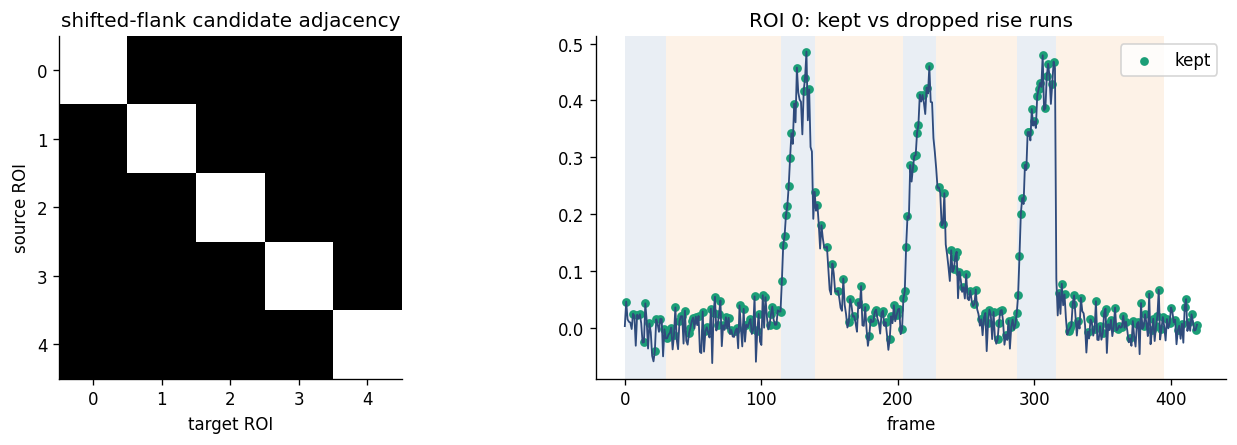

In [8]:
candidate_result = rise_flank_candidate_pairs(
    preview_bundle.rise,
    min_run_samples=MIN_RISE_RUN_SAMPLES,
    max_lag=RISE_MATCH_MAX_LAG,
    min_lag=RISE_MATCH_MIN_LAG,
    min_overlap_samples=RISE_MATCH_MIN_OVERLAP_SAMPLES,
    min_overlap_fraction=RISE_MATCH_MIN_OVERLAP_FRACTION,
    context_samples=RISE_RUN_CONTEXT_SAMPLES,
)

run_summary = pd.DataFrame(
    {
        "roi": np.arange(dataset.fluorescence.shape[0]),
        "kept_runs": candidate_result.runs.kept_counts,
        "dropped_runs": candidate_result.runs.dropped_counts,
        "kept_samples": [frames.size for frames in candidate_result.runs.event_indices],
        "context_samples": [frames.size for frames in candidate_result.event_indices],
    }
)
display(run_summary)

match_rows = [
    {
        "source": match.source,
        "target": match.target,
        "source_run": match.source_run,
        "target_run": match.target_run,
        "lag": match.lag,
        "overlap_count": match.overlap_count,
        "overlap_fraction": match.overlap_fraction,
        "source_start": match.source_start,
        "target_start": match.target_start,
    }
    for match in candidate_result.matches
]
display(pd.DataFrame(match_rows))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
axes[0].imshow(candidate_result.candidate_adjacency.astype(int), cmap="Greys", vmin=0, vmax=1)
axes[0].set_title("shifted-flank candidate adjacency")
axes[0].set_xlabel("target ROI")
axes[0].set_ylabel("source ROI")
axes[0].set_xticks(range(dataset.fluorescence.shape[0]))
axes[0].set_yticks(range(dataset.fluorescence.shape[0]))

roi = 0
add_phase_spans(axes[1], dataset)
axes[1].plot(time, dataset.fluorescence[roi], color="#2f4b7c", lw=1.1)
for run in candidate_result.runs.kept_runs[roi]:
    axes[1].scatter(run, dataset.fluorescence[roi, run], color="#1b9e77", s=18, label="kept" if run is candidate_result.runs.kept_runs[roi][0] else None)
for run in candidate_result.runs.dropped_runs[roi]:
    axes[1].scatter(run, dataset.fluorescence[roi, run], color="#d95f02", marker="x", s=22, label="dropped" if run is candidate_result.runs.dropped_runs[roi][0] else None)
axes[1].set_title(f"ROI {roi}: kept vs dropped rise runs")
axes[1].set_xlabel("frame")
handles, labels = axes[1].get_legend_handles_labels()
if handles:
    axes[1].legend(loc="upper right")
plt.show()


## Batch Trace View

Plot every trace in the currently generated batch with vertical offsets so the full simulated population can be inspected together.


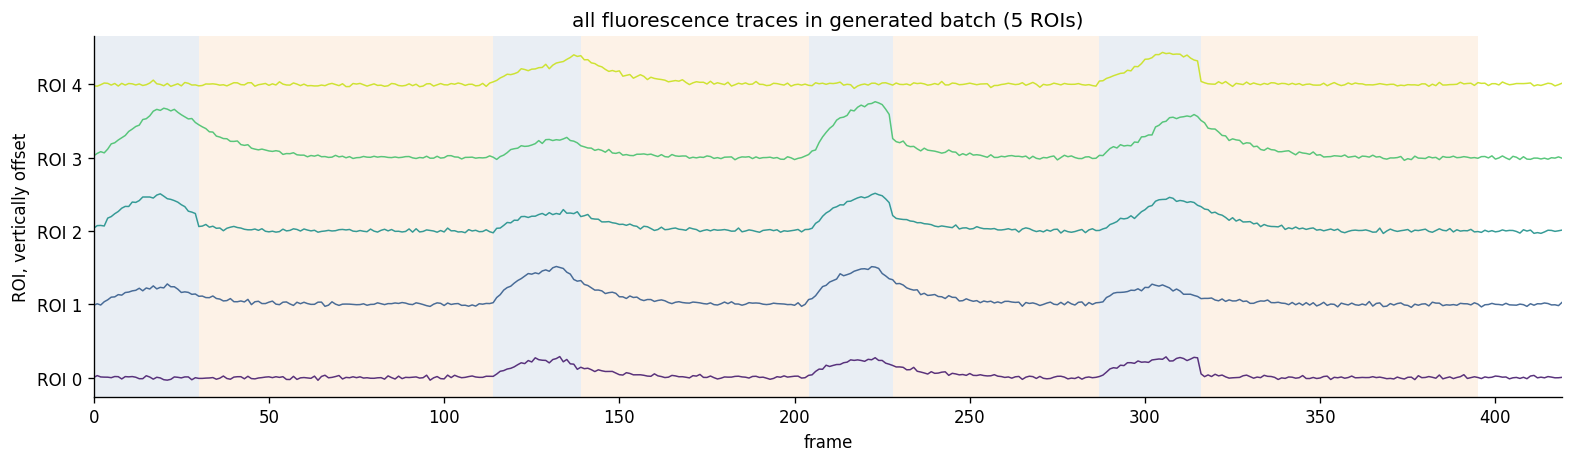

In [9]:
batch_traces = dataset.fluorescence
n_rois, n_frames = batch_traces.shape
time = np.arange(n_frames)
trace_range = np.ptp(batch_traces, axis=1)
offset_step = max(float(np.nanmax(trace_range)) * 1.25, 1e-6)
offsets = np.arange(n_rois, dtype=float) * offset_step

fig_height = max(3.2, min(0.35 * n_rois + 2.0, 14.0))
fig, ax = plt.subplots(figsize=(13, fig_height), constrained_layout=True)
add_phase_spans(ax, dataset)
colors = plt.cm.viridis(np.linspace(0.08, 0.92, n_rois))

for roi, color in enumerate(colors):
    ax.plot(
        time,
        batch_traces[roi] + offsets[roi],
        color=color,
        lw=0.9,
        alpha=0.9,
    )

ax.set_title(f"all fluorescence traces in generated batch ({n_rois} ROIs)")
ax.set_xlabel("frame")
ax.set_ylabel("ROI, vertically offset")
ax.set_yticks(offsets)
ax.set_yticklabels([f"ROI {roi}" for roi in range(n_rois)])
ax.set_xlim(0, n_frames - 1)
plt.show()

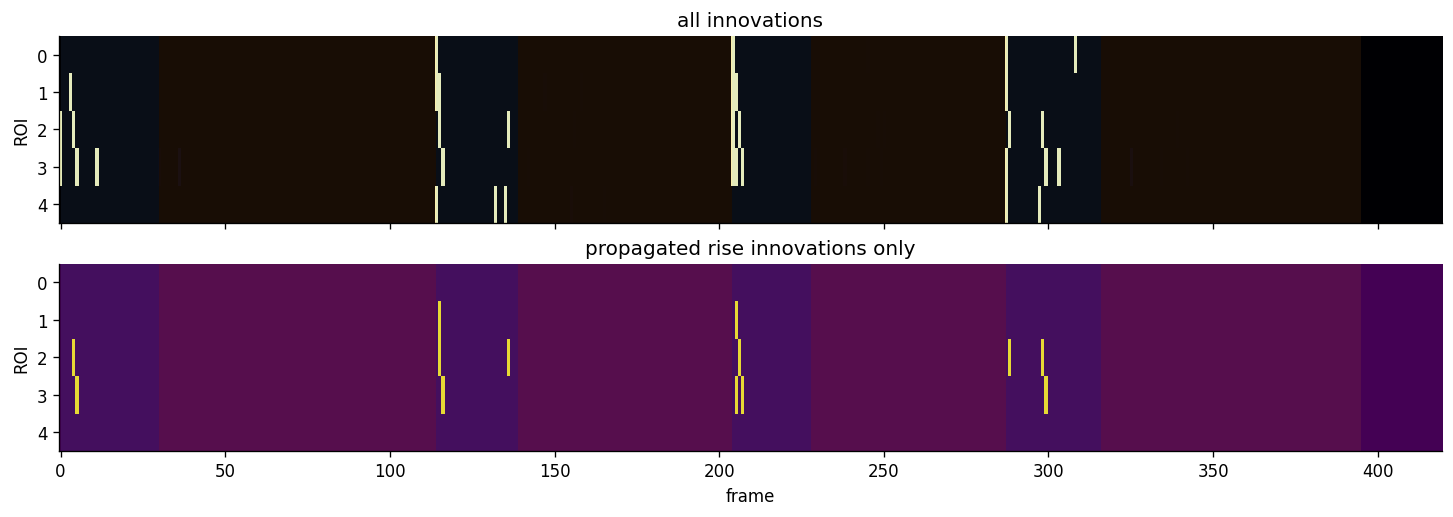

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 4.2), sharex=True, constrained_layout=True)
for ax in axes:
    add_phase_spans(ax, dataset)
axes[0].imshow(dataset.events, aspect="auto", interpolation="nearest", cmap="magma")
axes[0].set_title("all innovations")
axes[0].set_ylabel("ROI")
propagated = np.zeros_like(dataset.events) if dataset.propagated_events is None else dataset.propagated_events
axes[1].imshow(propagated, aspect="auto", interpolation="nearest", cmap="viridis")
axes[1].set_title("propagated rise innovations only")
axes[1].set_ylabel("ROI")
axes[1].set_xlabel("frame")
plt.show()

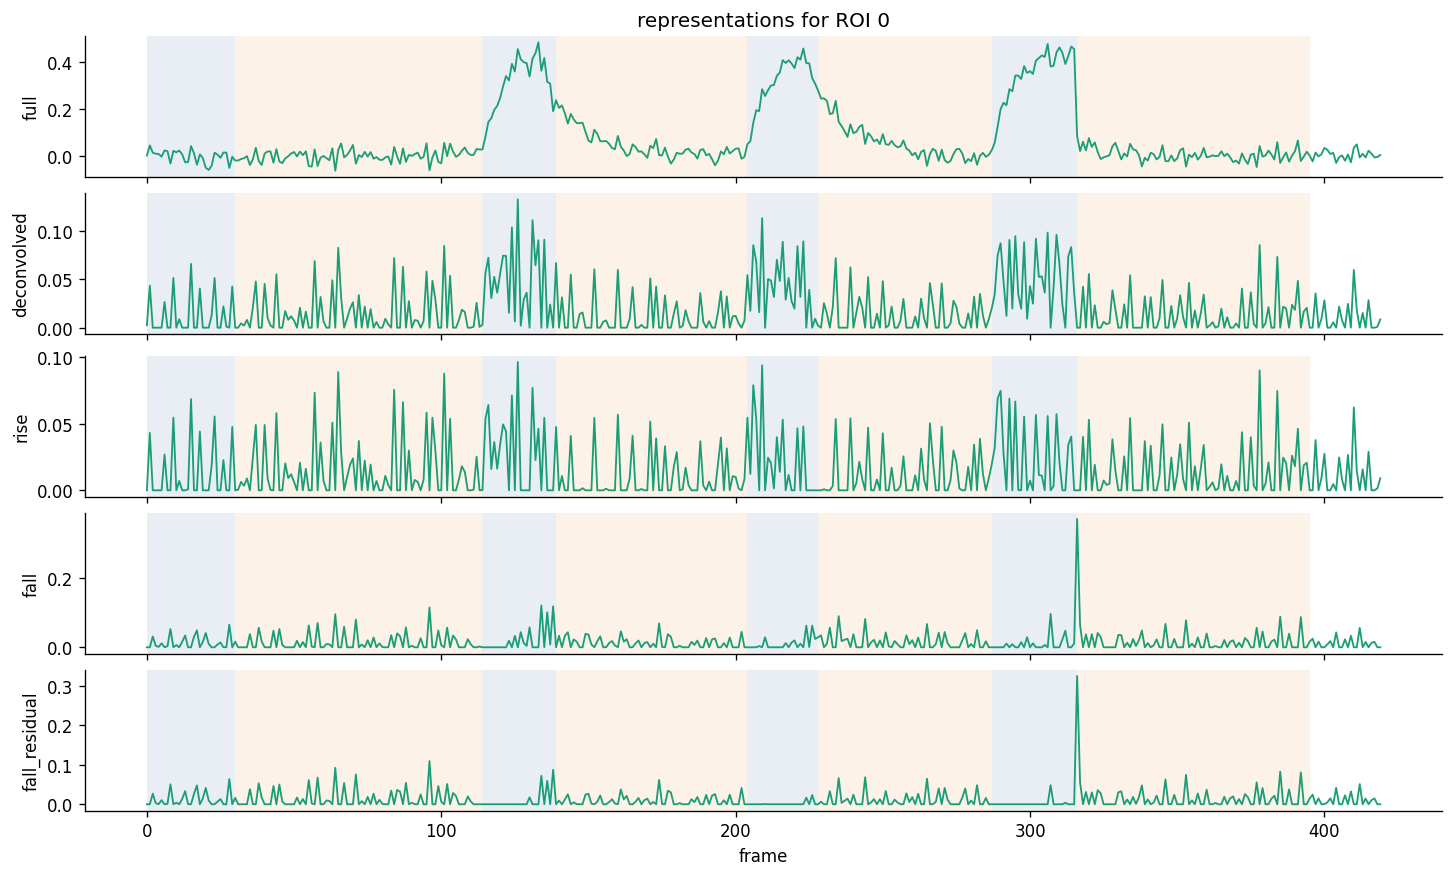

In [11]:
bundle = build_representations(dataset.fluorescence, tolerance=REPRESENTATION_TOLERANCE, gamma=GAMMA_RISE)
represented = bundle.as_dict()
roi = 0
fig, axes = plt.subplots(len(represented), 1, figsize=(12, 7.2), sharex=True, constrained_layout=True)
for ax, (name, values) in zip(axes, represented.items(), strict=True):
    add_phase_spans(ax, dataset)
    ax.plot(time, values[roi], color="#1b9e77", lw=1.1)
    ax.set_ylabel(name)
axes[0].set_title(f"representations for ROI {roi}")
axes[-1].set_xlabel("frame")
plt.show()

## Small Parameter Sweep

This is intended for exploration only. Keep the grid small while tuning the generator; use the scripted validation notebook for locked multi-seed runs.

,gamma_fall,fall_initial_scale,fall_initial_ceiling,seed,mean_rise_fluorescence,mean_fall_fluorescence,rise_event_rate,fall_event_rate,fall_propagated_total
0,0.82,0.5,0.6,2.0,0.409475,0.011840,0.067073,0.047773,0.0
1,0.82,0.5,0.8,2.0,0.409476,0.014015,0.067073,0.047773,0.0
2,0.82,0.5,1.0,2.0,0.409476,0.015851,0.067073,0.047773,0.0
3,0.82,1.0,0.6,2.0,0.409475,0.014342,0.067073,0.047773,0.0
4,0.82,1.0,0.8,2.0,0.409476,0.017821,0.067073,0.047773,0.0
5,0.82,1.0,1.0,2.0,0.409476,0.020608,0.067073,0.047773,0.0
6,0.82,1.5,0.6,2.0,0.409476,0.015692,0.067073,0.047773,0.0
7,0.82,1.5,0.8,2.0,0.409476,0.019490,0.067073,0.047773,0.0
8,0.82,1.5,1.0,2.0,0.409476,0.023062,0.067073,0.047773,0.0
9,0.90,0.5,0.6,2.0,0.409572,0.023154,0.067073,0.047773,0.0


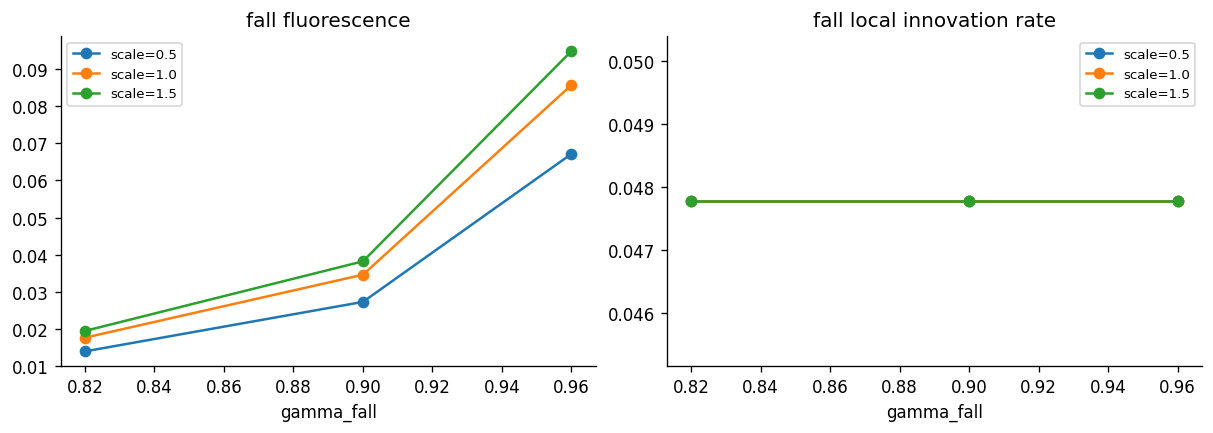

In [12]:
GAMMA_FALL_VALUES = [0.82, 0.90, 0.96]
FALL_INITIAL_SCALE_VALUES = [0.5, 1.0, 1.5]
FALL_INITIAL_CEILING_VALUES = [0.6, 0.8, 1.0]
SWEEP_SEEDS = [1, 2, 3]

rows = []
for gamma_fall in GAMMA_FALL_VALUES:
    for fall_initial_scale in FALL_INITIAL_SCALE_VALUES:
        for fall_initial_ceiling in FALL_INITIAL_CEILING_VALUES:
            for seed in SWEEP_SEEDS:
                cfg = replace(
                    dynamic_config,
                    gamma_fall=gamma_fall,
                    fall_initial_scale=fall_initial_scale,
                    fall_initial_ceiling_fraction=fall_initial_ceiling,
                )
                ds = simulate_calcium_dataset(
                    BASE_ADJACENCY,
                    n_steps=N_STEPS,
                    gamma=GAMMA_RISE,
                    noise_std=NOISE_STD,
                    shared_noise_std=SHARED_NOISE_STD,
                    spontaneous_rate=SPONTANEOUS_RATE,
                    transmission_probability=TRANSMISSION_PROBABILITY,
                    random_state=seed,
                    simulator_mode="episodic_dynamic",
                    dynamic_config=cfg,
                )
                labels = ds.phase_labels
                rise_mask = labels == 1
                fall_mask = labels == 2
                rows.append(
                    {
                        "gamma_fall": gamma_fall,
                        "fall_initial_scale": fall_initial_scale,
                        "fall_initial_ceiling": fall_initial_ceiling,
                        "seed": seed,
                        "mean_rise_fluorescence": float(ds.fluorescence[:, rise_mask].mean()),
                        "mean_fall_fluorescence": float(ds.fluorescence[:, fall_mask].mean()),
                        "rise_event_rate": float((ds.events[:, rise_mask] > 0).mean()),
                        "fall_event_rate": float((ds.events[:, fall_mask] > 0).mean()),
                        "fall_propagated_total": float(ds.propagated_events[:, fall_mask].sum()) if ds.propagated_events is not None else 0.0,
                    }
                )

sweep = pd.DataFrame(rows)
display(sweep.groupby(["gamma_fall", "fall_initial_scale", "fall_initial_ceiling"], as_index=False).mean(numeric_only=True))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
for scale, group in sweep.groupby("fall_initial_scale"):
    grouped = group.groupby("gamma_fall").mean(numeric_only=True)
    axes[0].plot(grouped.index, grouped["mean_fall_fluorescence"], marker="o", label=f"scale={scale}")
    axes[1].plot(grouped.index, grouped["fall_event_rate"], marker="o", label=f"scale={scale}")
axes[0].set_title("fall fluorescence")
axes[1].set_title("fall local innovation rate")
for ax in axes:
    ax.set_xlabel("gamma_fall")
    ax.legend(fontsize=8)
plt.show()

In [13]:
try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    widgets = None


if widgets is None:
    print("ipywidgets is not installed. Edit the parameter cell above and rerun instead.")
else:
    def preview(gamma_rise=0.90, gamma_fall=0.92, rise_waveform_length=20, fall_initial_scale=1.0, fall_initial_ceiling=1.0, source_dropout=0.15, source_recruitment=0.25, noise_std=0.025, seed=7):
        cfg = replace(
            dynamic_config,
            gamma_fall=gamma_fall,
            rise_waveform_length=rise_waveform_length,
            fall_initial_scale=fall_initial_scale,
            fall_initial_ceiling_fraction=fall_initial_ceiling,
            source_dropout_probability=source_dropout if TOPOLOGY_MODE == "generated" else dynamic_config.source_dropout_probability,
            source_recruitment_probability=source_recruitment if TOPOLOGY_MODE == "generated" else dynamic_config.source_recruitment_probability,
        )
        ds = simulate_calcium_dataset(
            BASE_ADJACENCY,
            n_steps=N_STEPS,
            gamma=gamma_rise,
            noise_std=noise_std,
            shared_noise_std=SHARED_NOISE_STD,
            spontaneous_rate=SPONTANEOUS_RATE,
            transmission_probability=TRANSMISSION_PROBABILITY,
            random_state=seed,
            simulator_mode="episodic_dynamic",
            dynamic_config=cfg,
        )
        fig, ax = plt.subplots(figsize=(11, 3))
        add_phase_spans(ax, ds)
        ax.plot(ds.fluorescence[0], color="#2f4b7c", lw=1.1)
        ax.set_title("ROI 0 fluorescence")
        ax.set_xlabel("frame")
        plt.show()

    display(
        widgets.interactive(
            preview,
            gamma_rise=widgets.FloatSlider(value=GAMMA_RISE, min=0.70, max=0.98, step=0.01),
            gamma_fall=widgets.FloatSlider(value=GAMMA_FALL, min=0.70, max=0.98, step=0.01),
            rise_waveform_length=widgets.IntSlider(value=RISE_WAVEFORM_LENGTH, min=1, max=MAX_RISE_LENGTH, step=1),
            fall_initial_scale=widgets.FloatSlider(value=FALL_INITIAL_SCALE, min=0.10, max=2.00, step=0.10),
            fall_initial_ceiling=widgets.FloatSlider(value=FALL_INITIAL_CEILING_FRACTION, min=0.00, max=1.00, step=0.05),
            source_dropout=widgets.FloatSlider(value=SOURCE_DROPOUT_PROBABILITY, min=0.00, max=1.00, step=0.05),
            source_recruitment=widgets.FloatSlider(value=SOURCE_RECRUITMENT_PROBABILITY, min=0.00, max=1.00, step=0.05),
            noise_std=widgets.FloatSlider(value=NOISE_STD, min=0.00, max=0.12, step=0.005),
            seed=widgets.IntSlider(value=RANDOM_STATE, min=1, max=100, step=1),
        )
    )

interactive(children=(FloatSlider(value=0.9, description='gamma_rise', max=0.98, min=0.7, step=0.01), FloatSli…